# 3 · Translation — Inference & Evaluation

1. Translate sample sentences (greedy decoding)
2. Compute BLEU, ROUGE, and token accuracy on the test set
3. Visualise Bahdanau attention heatmaps

## 0 · Configuration

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ── USER SETTING ──────────────────────────────────────────────────────────────
LANGUAGE        = 'french'   # must match what was preprocessed & trained
NUM_EVAL_PAIRS  = 200        # pairs to use for corpus-level metrics
NUM_PLOT_ATTN   = 3          # number of attention heatmaps to display
# ─────────────────────────────────────────────────────────────────────────────

print(f'Evaluating: {LANGUAGE.upper()}')

Evaluating: FRENCH


## 1 · Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.common import set_seed
from src.translation.dataset import load_translation_artifacts
from src.translation.predict import translate, load_model_for_language
from src.translation.metrics import compute_all_metrics, compute_corpus_bleu
from src.translation.utils import (
    sequence_to_sentence,
    plot_attention,
    get_attention_matrix,
    format_metrics_table,
)

set_seed(42)
print('Imports successful.')

Imports successful.


## 2 · Load Model & Test Data

In [3]:
model_data = load_model_for_language(LANGUAGE)
artifacts  = load_translation_artifacts(LANGUAGE)

eng_tok = artifacts['eng_tokenizer']
tgt_tok = artifacts['tgt_tokenizer']

# Decode test set back to strings for evaluation
eng_test_raw = [
    sequence_to_sentence(seq, eng_tok) for seq in artifacts['eng_test']
]
tgt_test_raw = [
    sequence_to_sentence(seq, tgt_tok) for seq in artifacts['tgt_test']
]

print(f'Test set size: {len(eng_test_raw):,}')

[INFO] Tokenizer loaded  ←  c:\Users\himan\Documents\trial 2\models\translation\english_french_tokenizer.pkl
[INFO] Tokenizer loaded  ←  c:\Users\himan\Documents\trial 2\models\translation\french_tokenizer.pkl


c:\Users\himan\Documents\ML project\venv\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


[INFO] Translation model loaded for language: french
[INFO] Tokenizer loaded  ←  c:\Users\himan\Documents\trial 2\models\translation\english_french_tokenizer.pkl
[INFO] Tokenizer loaded  ←  c:\Users\himan\Documents\trial 2\models\translation\french_tokenizer.pkl
Test set size: 10,000


## 3 · Quick Sample Translations

In [4]:
print(f'Sample Translations  (English → {LANGUAGE.capitalize()})')
print('=' * 70)

for i in range(min(10, len(eng_test_raw))):
    eng_src    = eng_test_raw[i]
    tgt_ref    = tgt_test_raw[i]
    result     = translate(eng_src, LANGUAGE)
    tgt_pred   = result['translation']

    metrics    = compute_all_metrics(tgt_ref, tgt_pred)

    print(f'  Source    : {eng_src}')
    print(f'  Reference : {tgt_ref}')
    print(f'  Predicted : {tgt_pred}')
    print(f'  BLEU      : {metrics["bleu"]:.2f}%   ROUGE-L: {metrics["rougeL"]:.2f}%')
    print()

Sample Translations  (English → French)
  Source    : i think that s an important point
  Reference : je pense que c est un point important
  Predicted : je pense que c est un tournant stupide
  BLEU      : 68.04%   ROUGE-L: 75.00%

  Source    : if we get out of here alive i ll buy you anything you want
  Reference : si nous d ici je t achète tout ce que tu veux
  Predicted : si vous voulez un endroit où je veux te rendre quelque chose
  BLEU      : 2.64%   ROUGE-L: 24.00%

  Source    : they have nothing to eat
  Reference : ils n ont rien à manger
  Predicted : elles n ont rien à manger
  BLEU      : 75.98%   ROUGE-L: 80.00%

  Source    : how many cups of coffee did you drink today
  Reference : combien de tasses de café avez vous déjà bues aujourd hui
  Predicted : combien de hot dogs as tu vendus aujourd hui
  BLEU      : 7.16%   ROUGE-L: 38.10%

  Source    : how do you pronounce this
  Reference : comment prononcez vous ceci
  Predicted : comment faites vous ça
  BLEU      : 7.

## 4 · Corpus-Level Metrics

In [5]:
eval_src  = eng_test_raw[:NUM_EVAL_PAIRS]
eval_ref  = tgt_test_raw[:NUM_EVAL_PAIRS]

all_predictions = []
all_metrics     = []

print(f'Running inference on {NUM_EVAL_PAIRS} test pairs...')
for src, ref in tqdm(zip(eval_src, eval_ref), total=NUM_EVAL_PAIRS):
    pred = translate(src, LANGUAGE)['translation']
    all_predictions.append(pred)
    all_metrics.append(compute_all_metrics(ref, pred))

# Average per-metric
avg_metrics = {}
for key in all_metrics[0]:
    avg_metrics[key] = round(np.mean([m[key] for m in all_metrics]), 2)

# Corpus BLEU
corpus_bleu_score = compute_corpus_bleu(eval_ref, all_predictions) * 100

print('\n--- Evaluation Results ---')
print(format_metrics_table(avg_metrics))
print(f'\nCorpus BLEU: {corpus_bleu_score:.2f}%')

Running inference on 200 test pairs...


100%|██████████| 200/200 [03:57<00:00,  1.19s/it]


--- Evaluation Results ---
Metric                    Score
────────────────────────────────
BLEU (%)                  23.20
ROUGE-1 (%)               53.04
ROUGE-2 (%)               31.96
ROUGE-L (%)               52.34
Token Accuracy (%)        38.56

Corpus BLEU: 25.13%


## 5 · Metric Distribution Plots

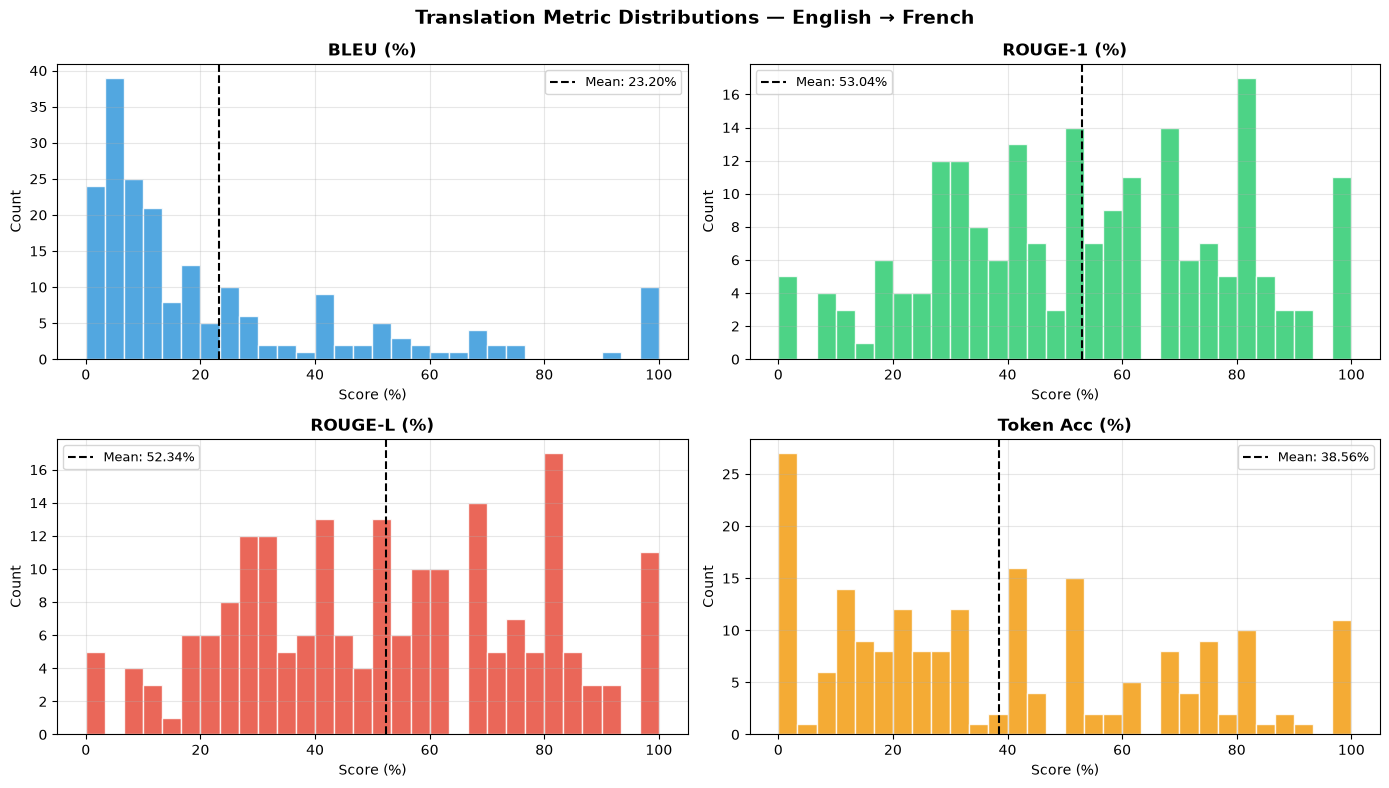

In [6]:
metric_keys = ['bleu', 'rouge1', 'rougeL', 'token_accuracy']
labels      = ['BLEU (%)', 'ROUGE-1 (%)', 'ROUGE-L (%)', 'Token Acc (%)']
colors      = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, key, label, color in zip(axes.flat, metric_keys, labels, colors):
    vals = [m[key] for m in all_metrics]
    ax.hist(vals, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(np.mean(vals), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(vals):.2f}%')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score (%)', fontsize=10)
    ax.set_ylabel('Count',     fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Translation Metric Distributions — English → {LANGUAGE.capitalize()}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'metric_distributions_{LANGUAGE}.png', dpi=120)
plt.show()

## 6 · Attention Heatmaps

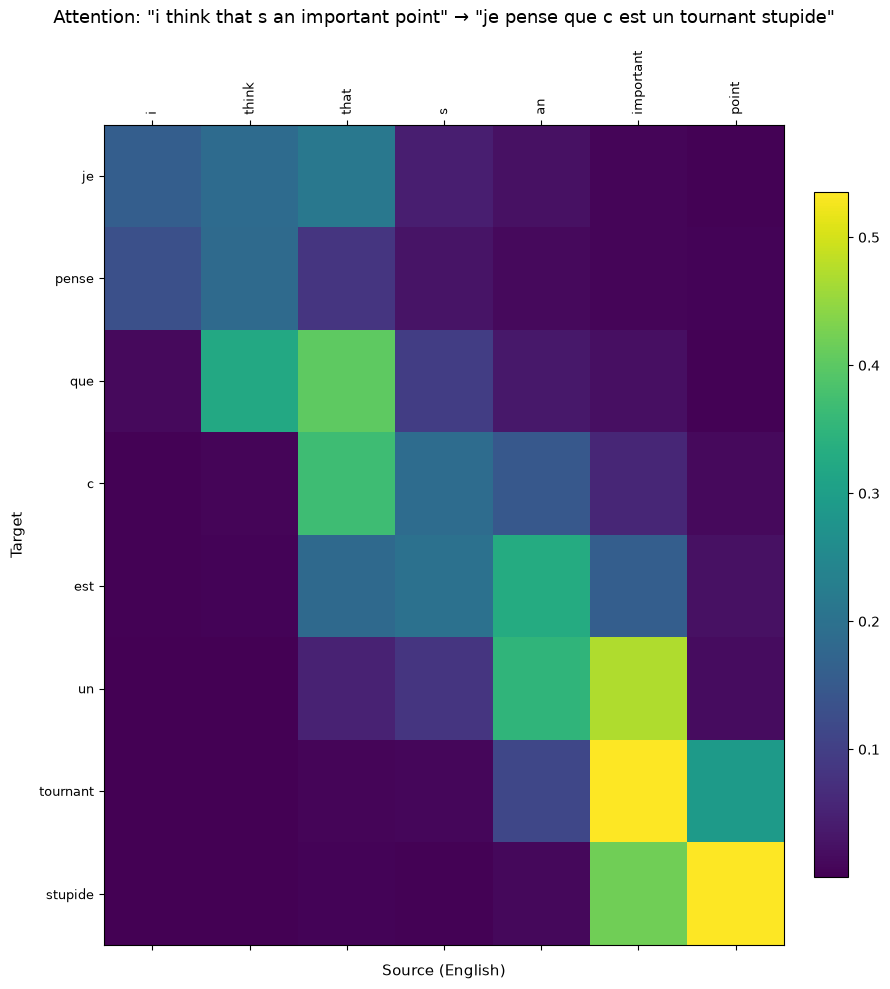

c:\Users\himan\Documents\ML project\venv\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


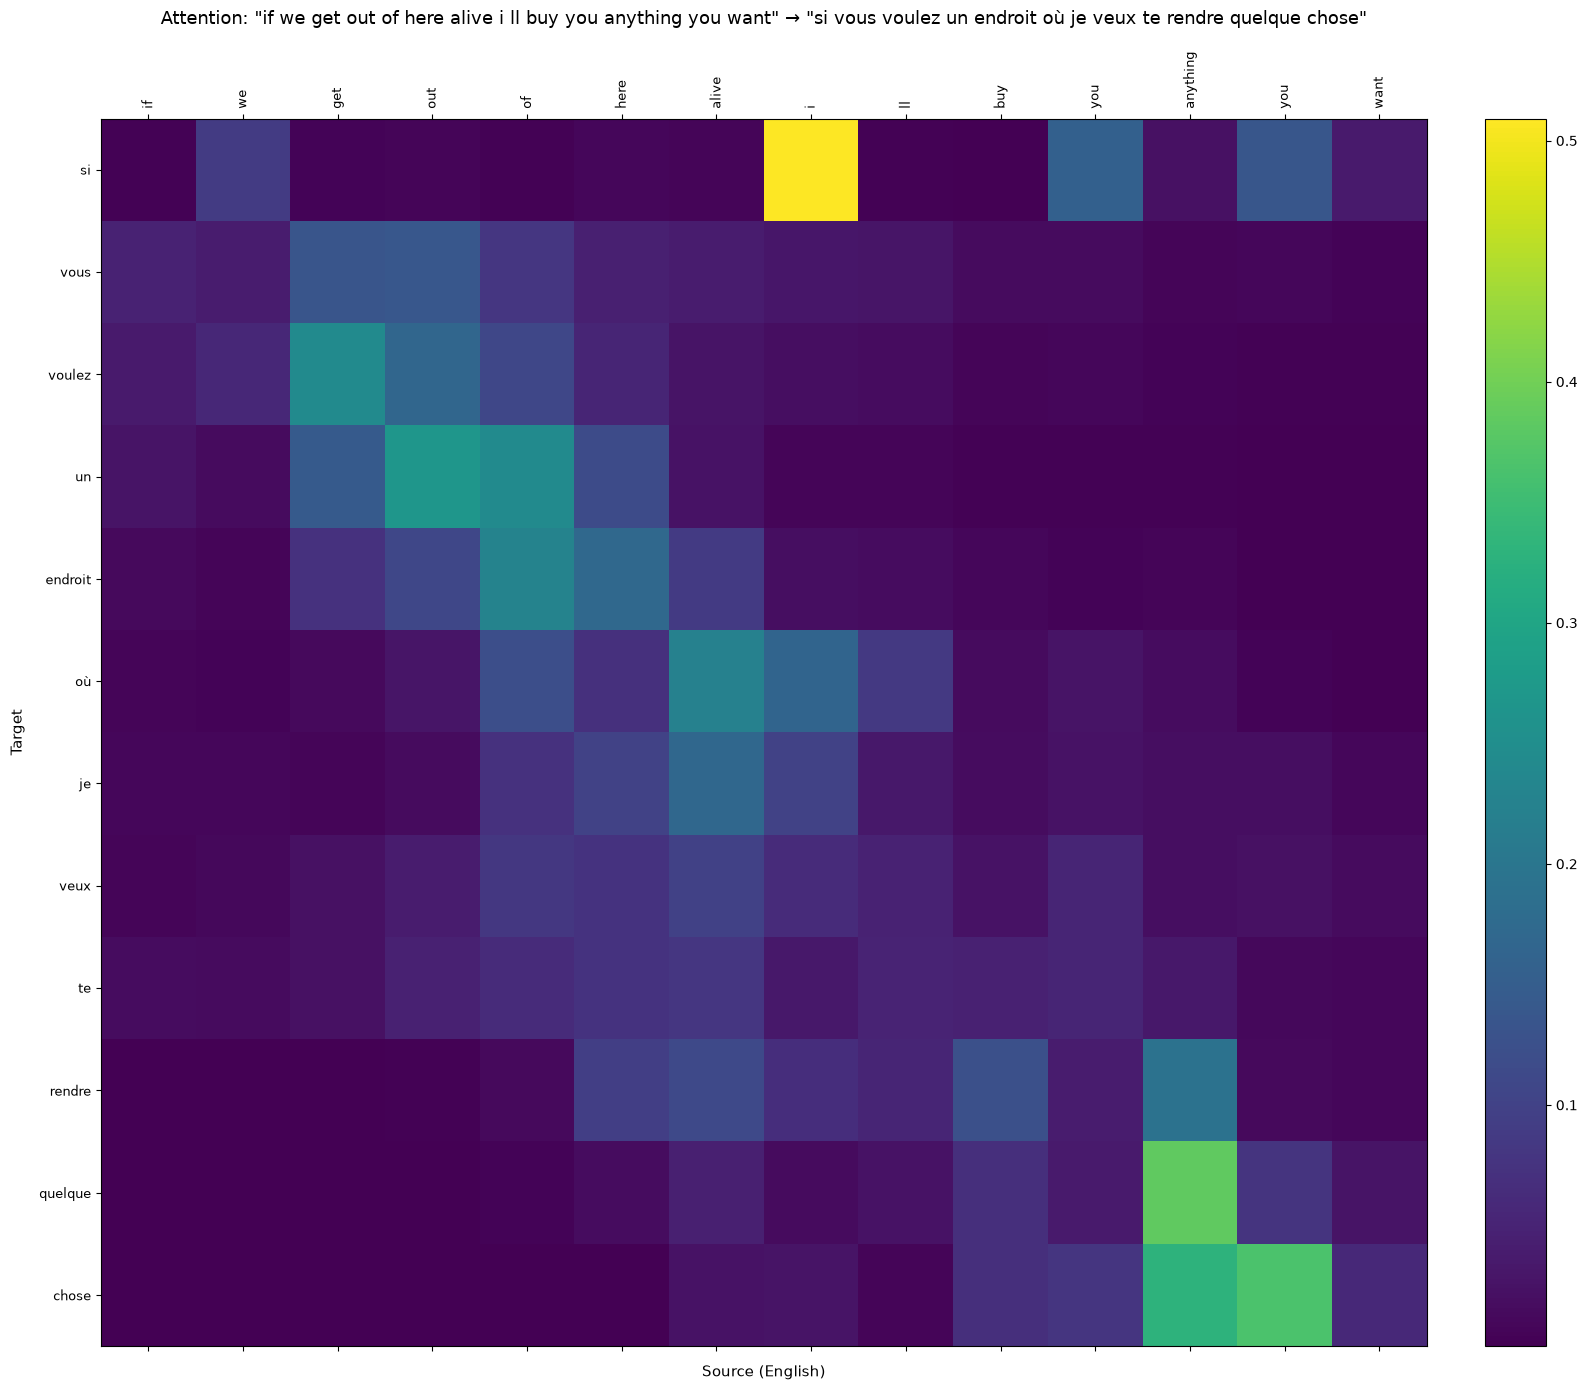

c:\Users\himan\Documents\ML project\venv\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


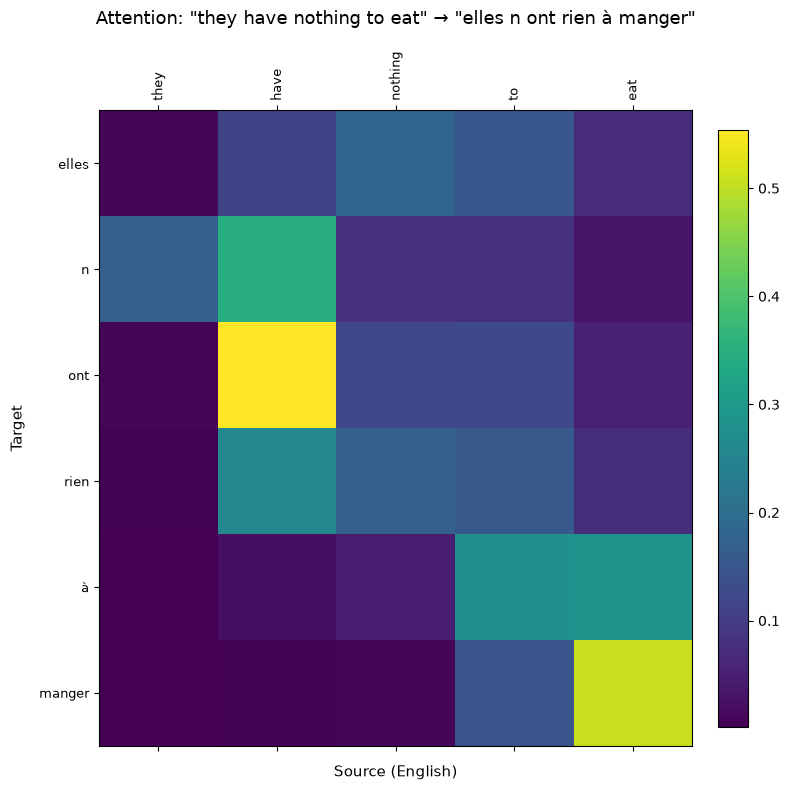

In [7]:
for i in range(NUM_PLOT_ATTN):
    src_text = eval_src[i]
    result   = translate(src_text, LANGUAGE)

    predicted_tokens = result['translation'].split()
    source_tokens    = src_text.split()
    attn_matrix      = get_attention_matrix(result['attention_weights'])

    if attn_matrix.size == 0:
        print(f'[Skip] Empty attention for: {src_text}')
        continue

    # Trim attention matrix to match token lengths
    attn_display = attn_matrix[
        :len(predicted_tokens),
        :len(source_tokens)
    ]

    fig = plot_attention(
        attn_display,
        source_tokens,
        predicted_tokens,
        title=f'Attention: "{src_text}" → "{result["translation"]}"',
    )
    plt.savefig(f'attention_{LANGUAGE}_{i}.png', dpi=100, bbox_inches='tight')
    plt.show()

## Evaluation Complete